# **Regression Project: Boston House Price Prediction**

# **Marks: 60**

Welcome to the project on regression. We will use the **Boston house price dataset** for this project.

-------------------------------
## **Objective**
-------------------------------

The problem at hand is to **predict the housing prices of a town or a suburb based on the features of the locality provided to us**. In the process, we need to **identify the most important features affecting the price of the house**. We need to employ techniques of data preprocessing and build a linear regression model that predicts the prices for the unseen data.

----------------------------
## **Dataset**
---------------------------

Each record in the database describes a house in Boston suburb or town. The data was drawn from the Boston Standard Metropolitan Statistical Area (SMSA) in 1970. Detailed attribute information can be found below:

Attribute Information:

- **CRIM:** Per capita crime rate by town
- **ZN:** Proportion of residential land zoned for lots over 25,000 sq.ft.
- **INDUS:** Proportion of non-retail business acres per town
- **CHAS:** Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
- **NOX:** Nitric Oxide concentration (parts per 10 million)
- **RM:** The average number of rooms per dwelling
- **AGE:** Proportion of owner-occupied units built before 1940
- **DIS:** Weighted distances to five Boston employment centers
- **RAD:** Index of accessibility to radial highways
- **TAX:** Full-value property-tax rate per 10,000 dollars
- **PTRATIO:** Pupil-teacher ratio by town
- **LSTAT:** % lower status of the population
- **MEDV:** Median value of owner-occupied homes in 1000 dollars

## **Importing the necessary libraries**

In [ ]:
#Libs to tidy data
import numpy as np
import pandas as pd

#Libs for visualisation
import seaborn as sb
import matplotlib.pyplot as plt
%matplotlib inline

#Libs for regression modeling
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")


### Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#Load the datset
boston_dataset = pd.read_csv('/content/drive/MyDrive/MIT Elective Project/Boston.csv')
data = boston_dataset.copy()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Overview

- Observations
- Sanity checks

In [ ]:
#Check the first 5 rows
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [ ]:
#Check the types for each col
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [ ]:
#Check for NA values
data.isna().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
#Check for duplicate values
data.duplicated().sum()

np.int64(0)

Observations:

*   The dataset has 506 rows and 12 columns
*   There are no missing values or duplicated values in the dataset
*   Most of the columns contain numerical values, except for 'CHAS' which is a binary, categorical variable

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions:**

1. What does the distribution of 'MEDV' look like?
2. What can we infer form the correlation heatmap? Is there correlation between the dependent and independent variables?
3. What are all the inferences that can be found by doing univariate analysis for different variables?
4. Do bivariate analysis to visualize the relationship between the features having significant correlations (>= 0.7 or <= -0.7)

In [ ]:
#Check statistics for each variable
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


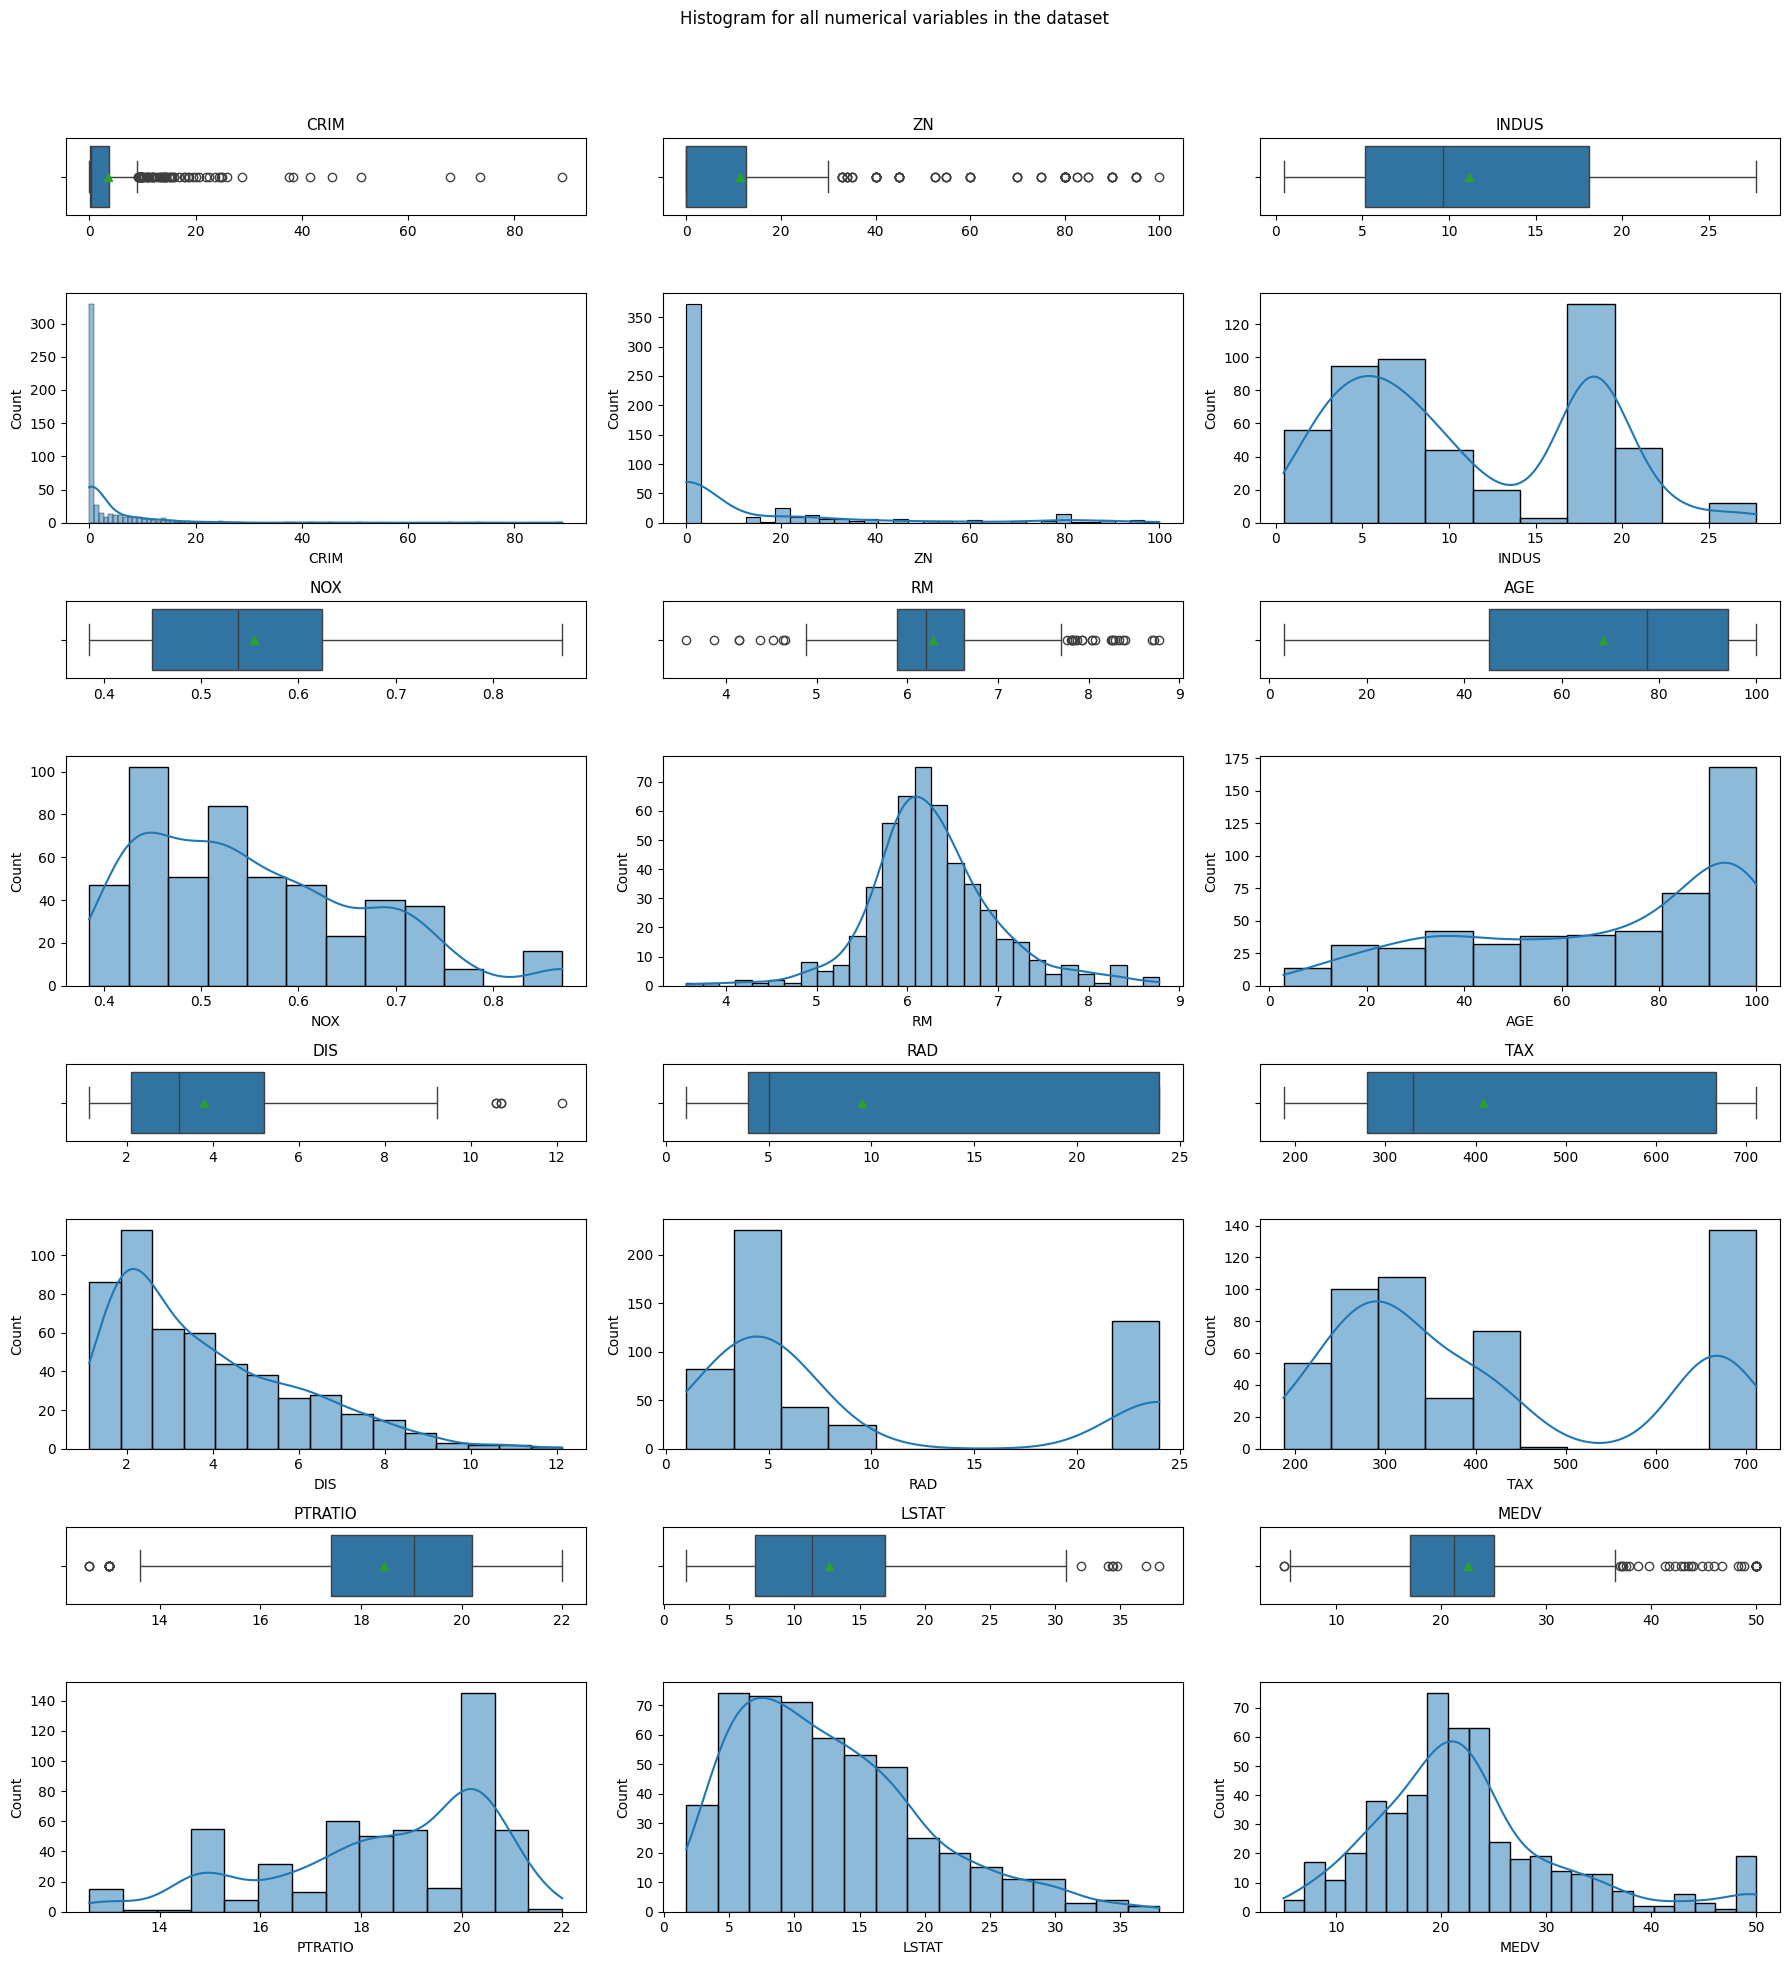

In [ ]:
#Univariate analysis - plot histogram for each numerical variable

#Define plot area and title
cols = [col for col in data.columns if col != 'CHAS']
n_cols = 3
n_rows = 4
n_groups = 4
fig, axes = plt.subplots(nrows=n_groups * 2,
                         ncols=n_cols,
                         figsize=(18, 20),
                         gridspec_kw={"height_ratios": [1, 3] * n_groups})

#Loop through each col in dataset and plot
for i, col in enumerate(cols):
    row = (i // n_cols) * 2   # Boxplot row
    c = i % n_cols            # Column

    # Boxplot
    sb.boxplot(x=data[col], ax=axes[row, c], showmeans=True)
    axes[row, c].set_title(col, fontsize=11)
    axes[row, c].set_xlabel("")

    # Histogram
    sb.histplot(data=data, x=col, kde=True, ax=axes[row + 1, c])
    axes[row + 1, c].set_xlabel(col)

fig.suptitle("Plots for all numerical variables in the dataset")

#Adjust spacing between subplots for better visualisation
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

CHAS
0    93.08
1     6.92
Name: proportion, dtype: float64


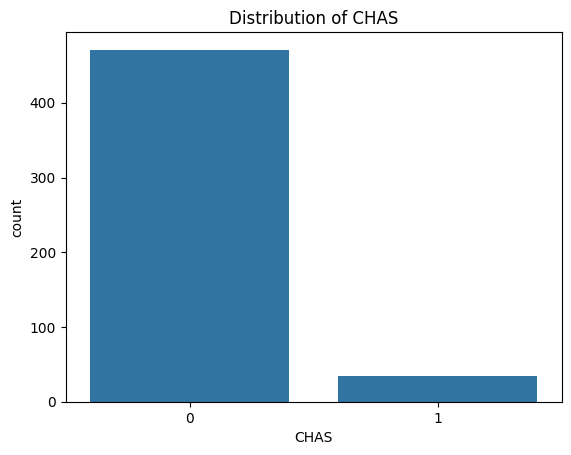

In [ ]:
#Univariate analysis - plot categorial variable
days_table = np.round(data["CHAS"].value_counts(normalize=True) *100, 2)
print(days_table)

sb.countplot(data, x='CHAS')
plt.title('Distribution of CHAS')
plt.show()

Observations:

*   CRIM and ZN are highly skewed to the right with many outliers. This shows us that the crime rate by town is generally low, but can be very high for some areas, and the proportion of land zoned for lots over 25,000 sqft is generally low, but can be very high for some areas.

*   RM is normally distributed, suggesting the average number of rooms per house across all towns is 6.

*   INDUS, RAD and TAX all show a bimodal distribution, with two distinct peaks observed. For non-retail businesses per town, this shows some towns have low proportions of businesses (5) while other towns have much higher proportions of businesses (17). Similarly, some towns have low accessibility (5) to radial highways, while others have higher accessibility (22), and the property-tax rate of houses can peak at either \$ 300,000 or \$ 700,000.

*   CHAS shows us that most houses (93%) are not bound to the river.

*   NOX is slightly skewed to the right, but ranges tightly between 0.4 to 0.8 parts per 10 million. Thus, there is not a large difference across towns with the nitric oxide concentration.

*   AGE is skewed to the left and shows us that most houses were built before 1940.

*   DIS and LSTAT are both rightly skewed with few outliers noted. This suggests the distances of houses to the Boston employment centres are low, with most houses within 3.2 mean weighted distance away from a centre. Similarly, most houses are within regions of higher population status, with a mean value of 11% low status noted, while only a few houses are within regions of 35% low status.

*   PTRATIO is variable but slightly skewed to the left. This suggests most houses are in towns with varying pupil-teacher ratios, but the mean value is 18.5.

*   MEDV is skewed to the right, with several outliers noted. The median value of a house is \$21,000, but there are several properties that are valued \$50,000.


Overall, this analysis displays several features with outliers, high skewness and variable distributions. The bimodal distributions suggest there may be distinct groups of towns present Boston area and the value of houses may be different based on these features.


<Axes: >

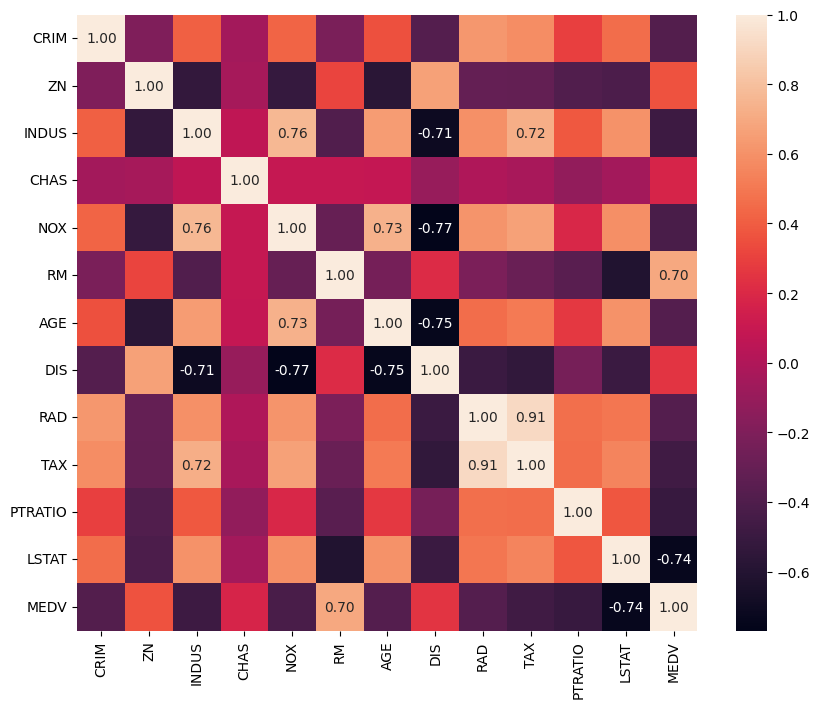

In [ ]:
#Bivariate analysis - plot heatmap correlation

#Annotate only the variables > 0.7 or < -0.7
corr = data[['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
             'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO',
             'LSTAT', 'MEDV']].corr()
annot = corr.apply(lambda col: col.map(lambda x: f"{x:.2f}" if abs(round(x, 2)) >= 0.70 else ""))

#Plot heatmap
fig, ax = plt.subplots(figsize=(10,8))
sb.heatmap(data[['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'MEDV']].corr(),
           annot=annot,
           fmt="")

Observations:

*   MEDV is positively correlated with RM (0.7) and negatively correlated with LSTAT (-0.74).
*   Some independent variables are highly correlated with each other, which is not ideal for linear regression. INDUS is correlated with NOX, DIS and TAX. NOX is correlated with AGE and DIS. AGE is correlated with DIS. RAD is highly correlated with TAX. We can assess the multi-colinearity affect in the model metrics and remove the variables if needed.




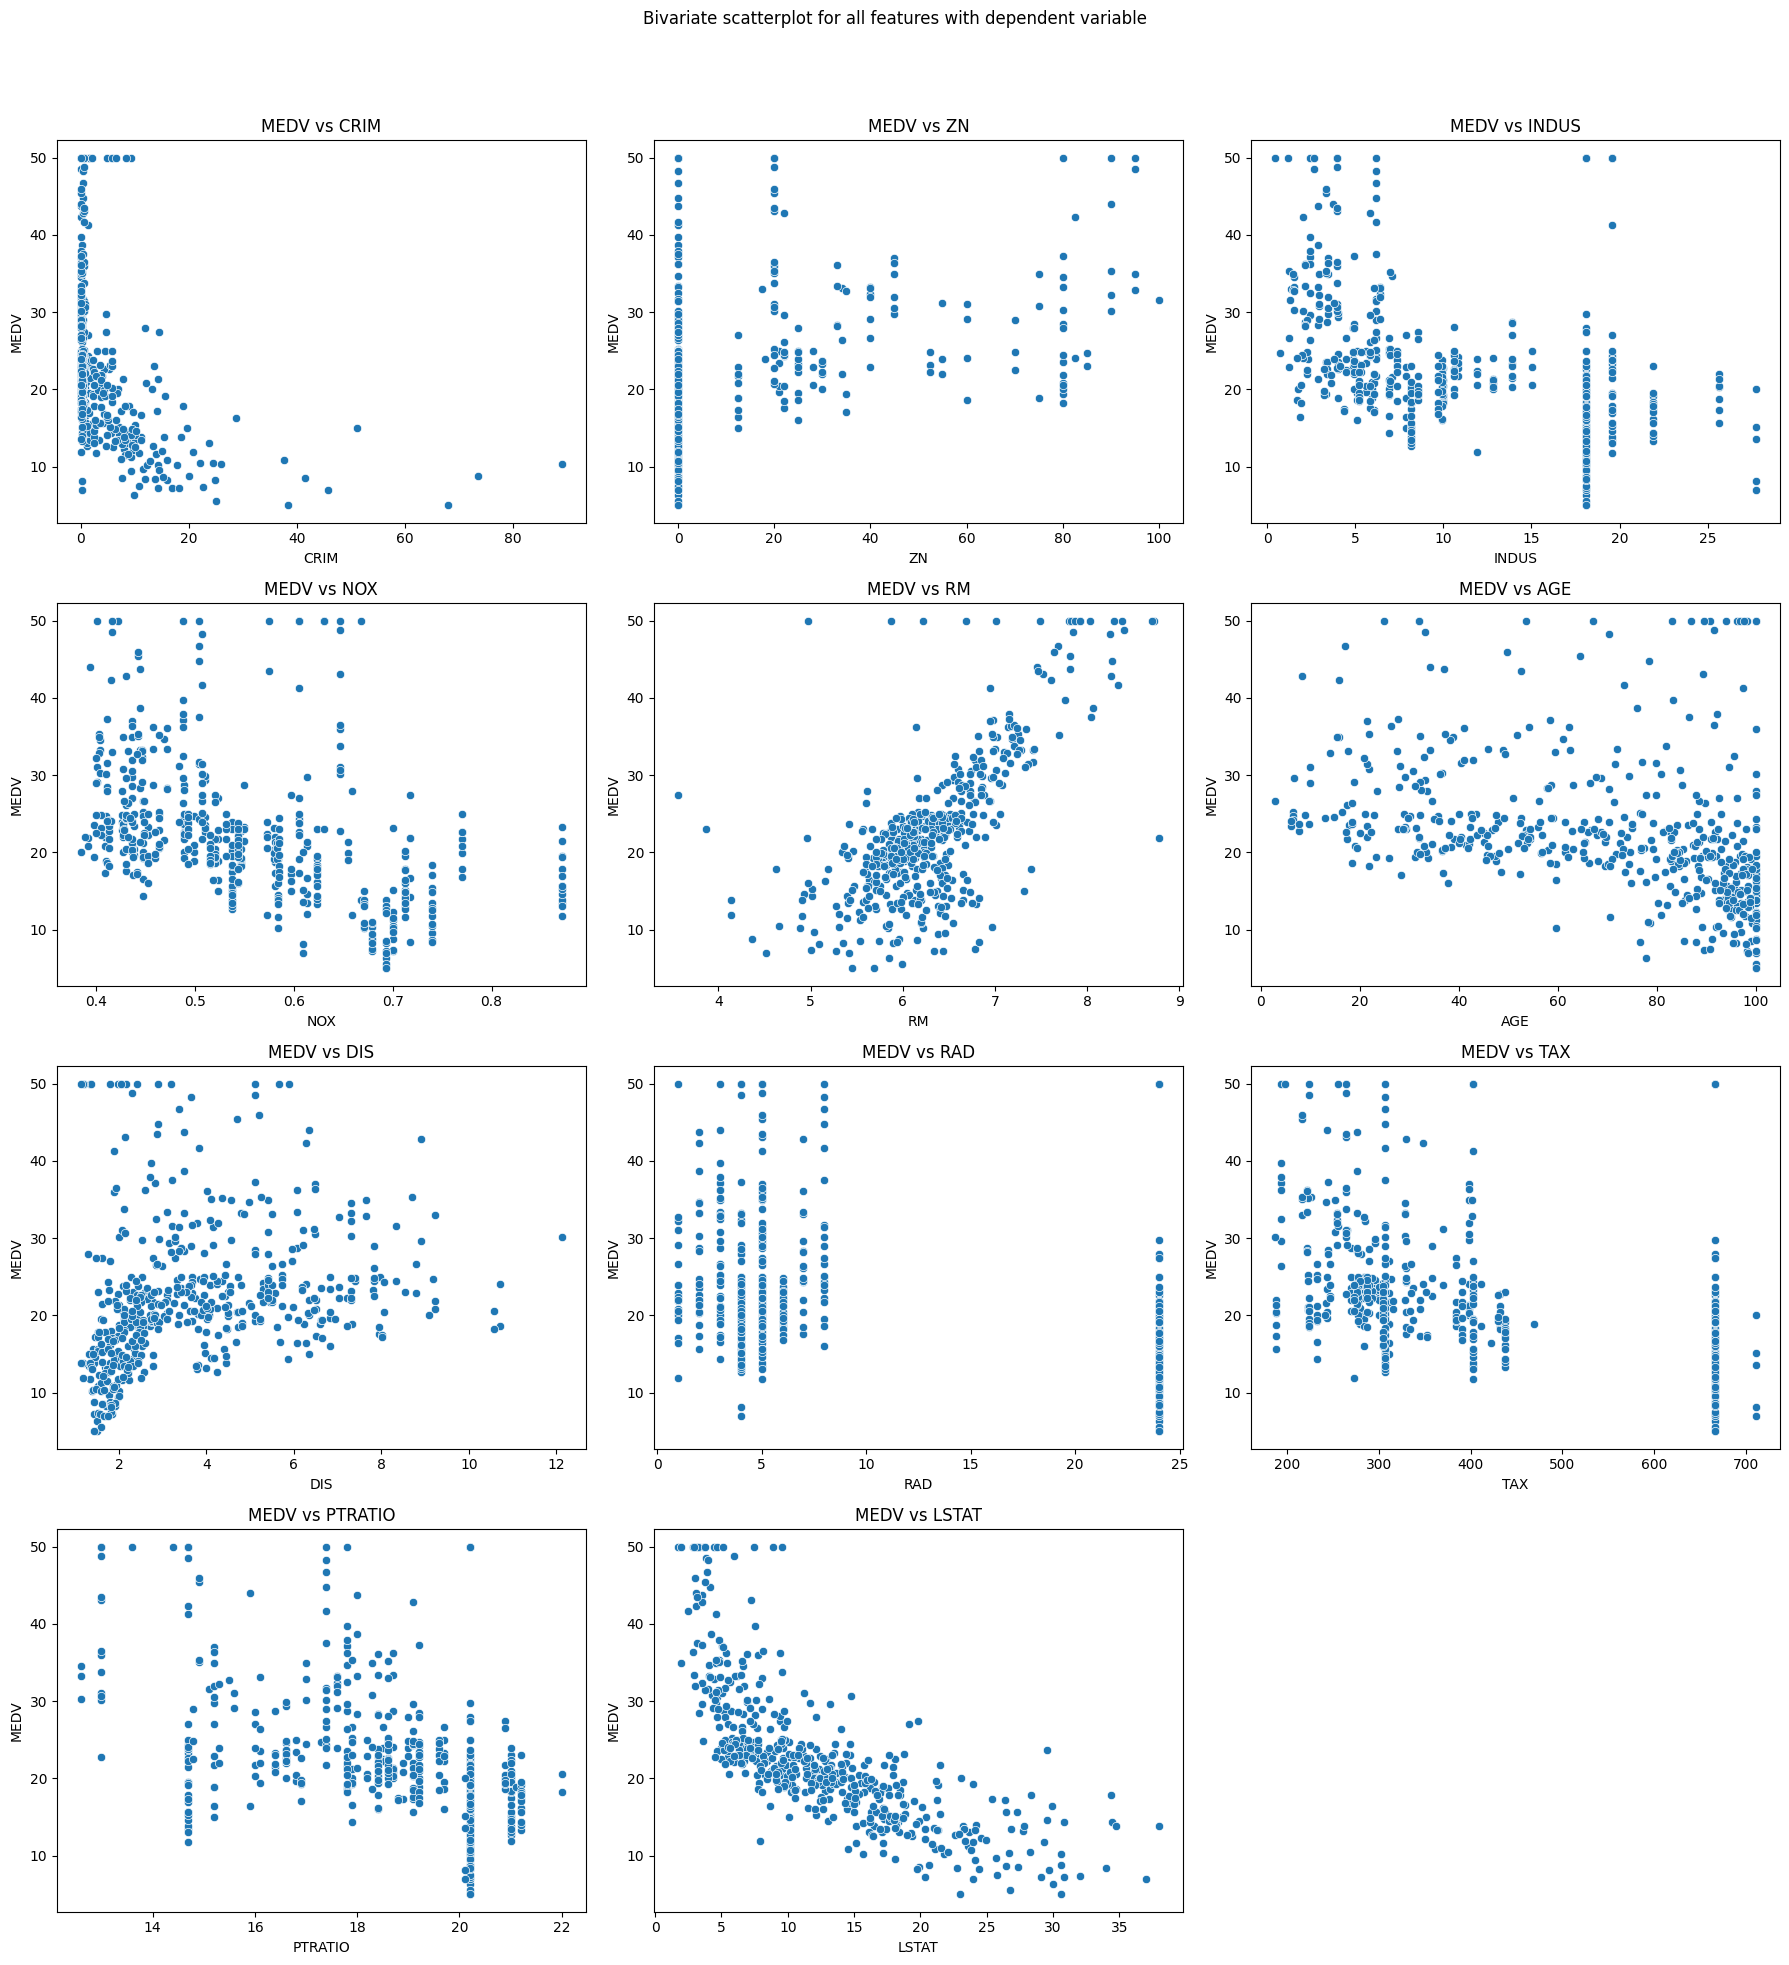

In [ ]:
#Bivariate analysis - relationship between MEDV and each independent numerical variable

#Define plot area and title
predictors = [col for col in data.columns if col not in ['MEDV', 'CHAS']]
n_cols = 3
n_rows = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

#Loop through each col in dataset and plot
for ax, col in zip(axes, predictors):
    sb.scatterplot(data, x=col, y='MEDV', ax=ax)
    ax.set_title(f"MEDV vs {col}")
fig.suptitle("Bivariate scatterplot for all features with dependent variable")

#Remove empty plot boxes
for ax in axes[len(predictors):]:
    fig.delaxes(ax)

#Adjust spacing between subplots for better visualisation
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

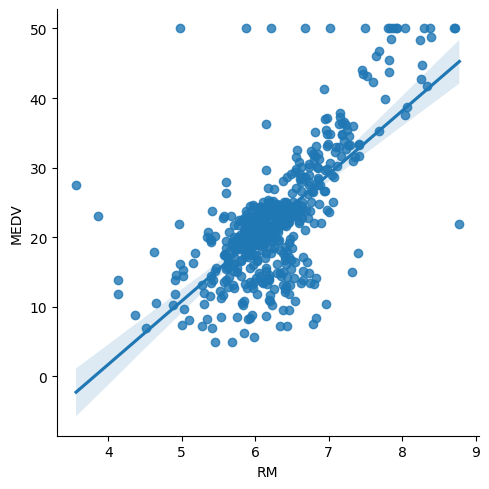

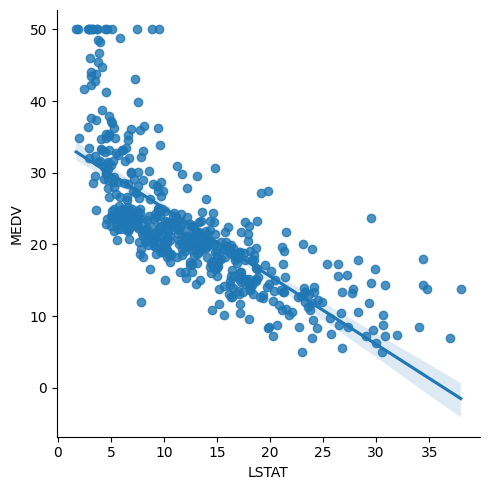

In [ ]:
#Bivariate analysis - observe homoscedasticity between MEDV and RM and LSTAT

sb.lmplot(data, x='RM', y='MEDV')
sb.lmplot(data, x='LSTAT', y='MEDV')

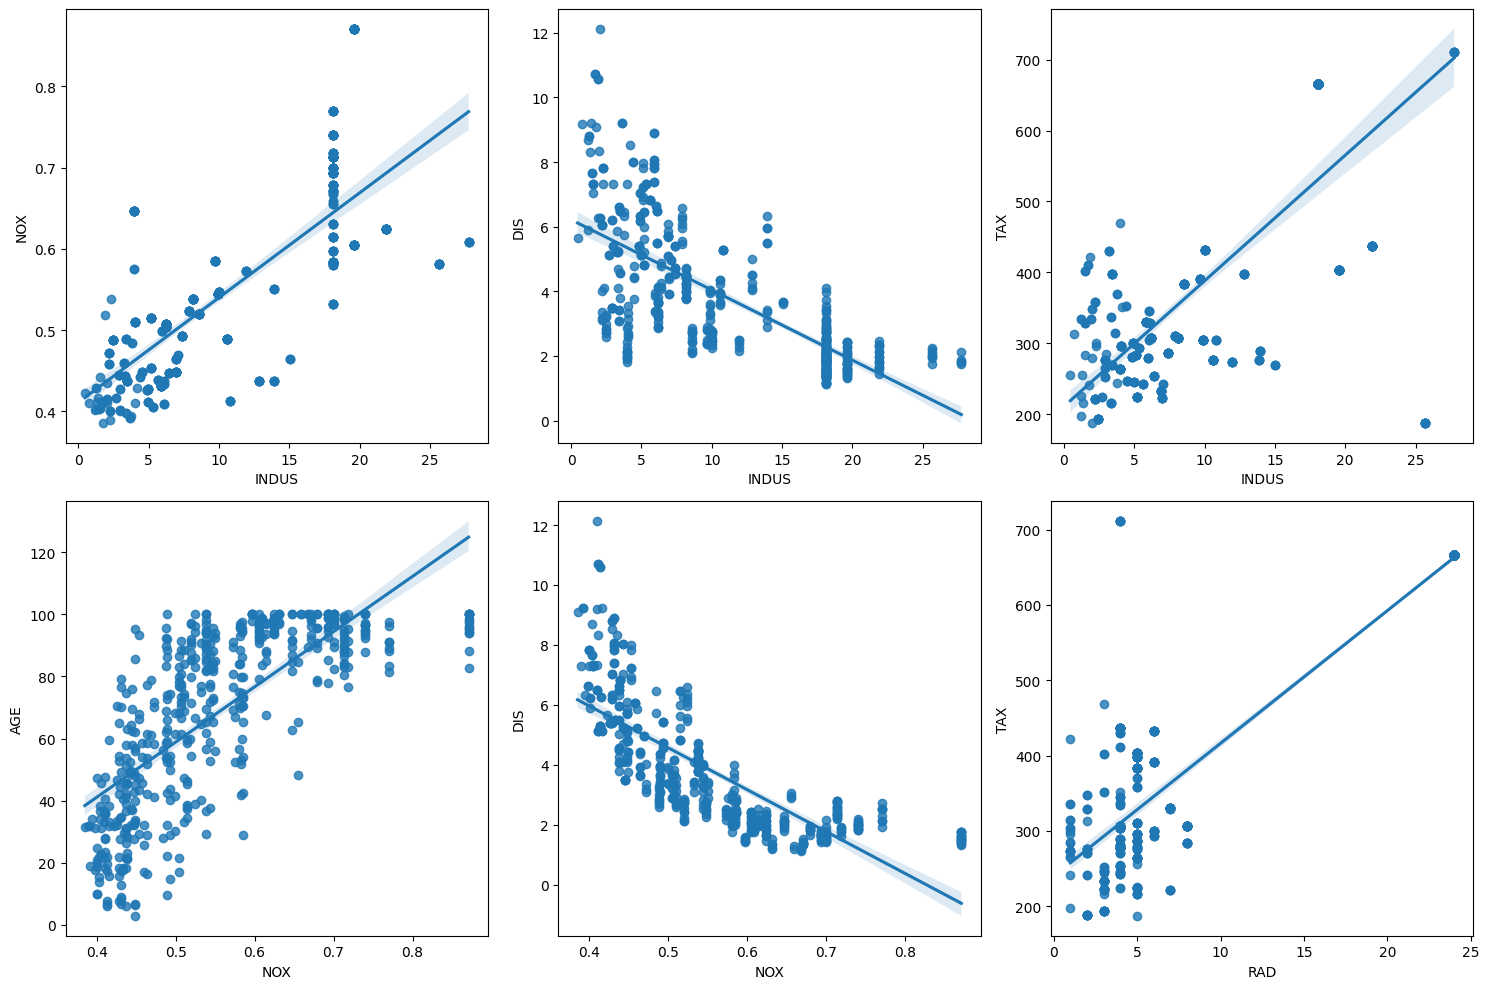

In [ ]:
#Bivariate analysis - observe the highly correlated independent variables

fig, axes = plt.subplots(2, 3, figsize=(15,10))

sb.regplot(data, x='INDUS', y='NOX', ax=axes[0,0])
sb.regplot(data, x='INDUS', y='DIS', ax=axes[0,1])
sb.regplot(data, x='INDUS', y='TAX', ax=axes[0,2])
sb.regplot(data, x='NOX', y='AGE', ax=axes[1,0])
sb.regplot(data, x='NOX', y='DIS', ax=axes[1,1])
sb.regplot(data, x='RAD', y='TAX', ax=axes[1,2])

plt.tight_layout()
plt.show()

Observations:

*   Most independent variables do not correlate well with or have a linear relationship with MEDV, apart from RM and LSTAT.
*   For RM, as the number of rooms per house increases, the median value of the house increases. However, there are a few outliers at \$50,000.
*   For LSTAT, as the percentage of low status individuals decrease, the house price increases, with the most expensive houses having less than 5% of the population with low socioeconomic status.
*   No heteroscedasticity is observed between MEDV with RM or LSTAT, showing a constant variance along the line of best fit.  

Overall, both RM and LSTAT seem like they would be good predictors for MEDV when performing linear regression modeling.


When investigating the independent variables that are highly correlated, we find:
*   INDUS and DIS are negatively correlated. This suggests as distance to Boston employment centres decreases, the proportion of non-retail businesses in town increases. This makes sense given the typical layout of a town, where you would expect to find more shops and businesses around the town centre where the employment centre would be located.
*   INDUS and NOX and INDUS and TAX are both positively correlated. There does not seem to be an obvious reason why this might be.
*   AGE and NOX are positively correlated, with higher nitric oxide concentration seen in older houses.
*   DIS and NOX are negatively correlated. This suggests that as distance of houses to employment centres decreases, the nitric oxide concentration increases. This could suggest that older houses are located closer to the employment centres and would explain the correlation between AGE, DIS and NOX.
*   RAD and TAX are positively correlated, but with clear outliers present that may be skewing the correlation. Both RAD and TAX variables were found to have skewed data when observing univariate analysis, with two distinct groups observed (low tax group and high tax group; low accessibility to highways and high accessibility to highways). This difference in groups could be accounted for during regression modeling by feature engineering (creating groups to better account for the variability we see).




## Data Preprocessing

- Missing value treatment
- Log transformation of dependent variable if skewed
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

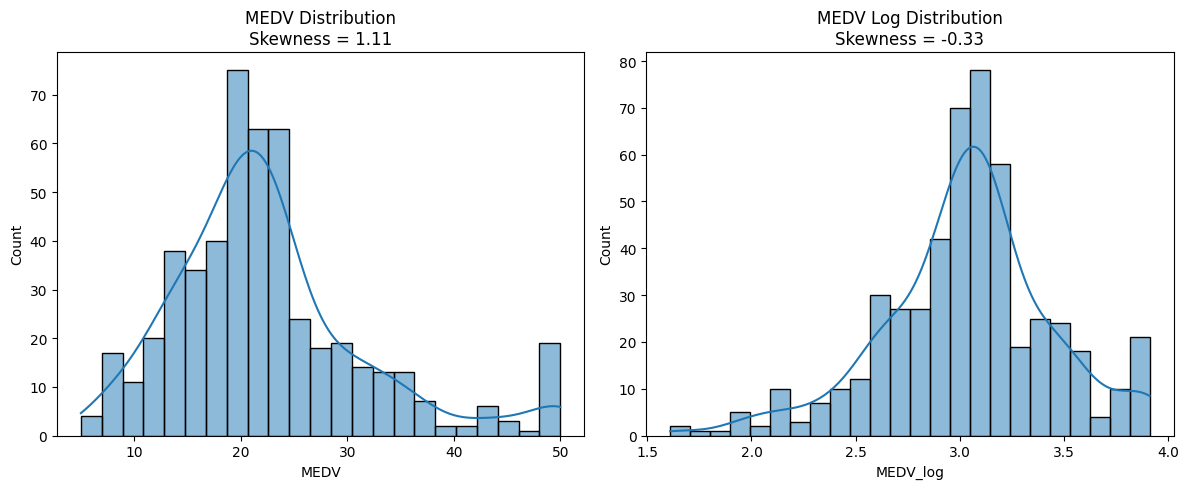

In [ ]:
#Check skewness of MEDV, if log transformation is needed
medv_skew = data['MEDV'].skew()

#Given the skew value is >1, MEDV is highly skewed and transforming it might help with model prediction
data['MEDV_log'] = np.log(data['MEDV'])

#Check log transformed variable
medvlog_skew = data['MEDV_log'].skew()

#Plot before and after transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sb.histplot(data, x='MEDV', kde=True, ax=axes[0])
axes[0].set_title(f"MEDV Distribution\nSkewness = {medv_skew:.2f}")

sb.histplot(data, x='MEDV_log', kde=True, ax=axes[1])
axes[1].set_title(f"MEDV Log Distribution\nSkewness = {medvlog_skew:.2f}")

plt.tight_layout()
plt.show()


In [ ]:
#Preparing data for modeling
from sklearn.model_selection import train_test_split

#Split data up into 'y' dependent and 'X' independent variables
dependent_var = data['MEDV_log']
independent_vars = data.drop(columns=['MEDV', 'MEDV_log'])

#Add the intercept term because we are using statsmodel package and this is not done for us automatically
independent_vars = sm.add_constant(independent_vars)

#Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(independent_vars, dependent_var, test_size = 0.30, random_state = 1)

#Check size of train and test sets
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(354, 13)
(152, 13)
(354,)
(152,)


Notes on data preprocessing:


*   There were no missing values in the dataset, so we did not treat for missing values.
*   Our dependent variable, MEDV, was skewed to the right, so we decided to log transform the variable. We can test whether this transformation helps improve the model's prediction.

*   Outliers were noted in some independent variables, however these are not due to error and will not be removed.
*   The data was prepared for modeling by splitting the data into X and Y features, and subsequently into training and test datasets.


## Model Building - Linear Regression

In [ ]:
#Call and fit the OLS model
ols_model_1 = sm.OLS(y_train, X_train).fit()

print(ols_model_1.summary())

                            OLS Regression Results                            
Dep. Variable:               MEDV_log   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     97.19
Date:                Sun, 02 Aug 2026   Prob (F-statistic):          3.27e-102
Time:                        13:56:56   Log-Likelihood:                 80.575
No. Observations:                 354   AIC:                            -135.1
Df Residuals:                     341   BIC:                            -84.85
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6856      0.241     19.404      0.0

Observations:

*   The R-squared value for Model 1 is 0.774, which suggests the model can predict MEDV reasonably well given the current features, but there is room for improvement.
*   The coefficient value remains low for each independent variable, which means no single variable is greatly influencing MEDV predicition.
*   The p-value is statistically significant for most variables, except for INDUS and AGE where the p-value is >0.05.
*   The model suggests strong multicollinearity is present, which we will investigate further to improve model performance.




## Model Performance Check

1. How does the model is performing? Check using Rsquared, RSME, MAE, MAPE
2. Is there multicollinearity? Check using VIF
3. How does the model is performing after cross validation?

In [ ]:
#Check for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Calculate VIF score
vif_series = pd.Series(
    [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])],
    index = X_train.columns,
    dtype = float)

print("VIF Scores: \n\n{}\n".format(vif_series))

VIF Scores: 

const      535.372593
CRIM         1.924114
ZN           2.743574
INDUS        3.999538
CHAS         1.076564
NOX          4.396157
RM           1.860950
AGE          3.150170
DIS          4.355469
RAD          8.345247
TAX         10.191941
PTRATIO      1.943409
LSTAT        2.861881
dtype: float64



Observations:



*   When accessing multicollinearity, we observe two variables with high VIF scores - RAD and TAX. This suggests the model is impacted by these two variables as they have high correlation with other features. This is not suprising given the correlation we observed during EDA.
*   We will remove these two variables and assess the model performance again.



In [ ]:
#Drop RAD and TAX
X_train_m2 = X_train.drop(columns=['RAD', 'TAX'])

#Calculate VIF score
vif_series = pd.Series(
    [variance_inflation_factor(X_train_m2.values, i) for i in range(X_train_m2.shape[1])],
    index = X_train_m2.columns,
    dtype = float)

print("VIF Scores: \n\n{}\n".format(vif_series))

#Call and fit the OLS model
ols_model_2 = sm.OLS(y_train, X_train_m2).fit()

print(ols_model_2.summary())

VIF Scores: 

const      437.477876
CRIM         1.489478
ZN           2.450078
INDUS        3.231542
CHAS         1.050455
NOX          3.797986
RM           1.776020
AGE          3.124657
DIS          4.333481
PTRATIO      1.558200
LSTAT        2.858053
dtype: float64

                            OLS Regression Results                            
Dep. Variable:               MEDV_log   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     108.2
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           1.02e-99
Time:                        13:56:56   Log-Likelihood:                 69.652
No. Observations:                 354   AIC:                            -117.3
Df Residuals:                     343   BIC:                            -74.74
Df Model:                          10                                         
Covariance Type: 

Observations:

*   After dropping RAD and TAX variables, there is no significant multicollinearity noted across any other variables. Additionally, the second model's performance metrics stay similar, with R-squared value at 0.759, suggesting that these two variables had no impact on the model's performance.
*   Looking at the second model's performance, we observe two variables with high p-values above 0.05 - INDUS and AGE. We will remove these variables as they are insignificant to the model's performance.



In [ ]:
#Remove INDUS and AGE
X_train_m3 = X_train_m2.drop(columns=['INDUS', 'AGE'])

#Calculate VIF score
vif_series = pd.Series(
    [variance_inflation_factor(X_train_m3.values, i) for i in range(X_train_m3.shape[1])],
    index = X_train_m3.columns,
    dtype = float)

print("VIF Scores: \n\n{}\n".format(vif_series))

#Call and fit the OLS model
ols_model_3 = sm.OLS(y_train, X_train_m3).fit()

print(ols_model_3.summary())

VIF Scores: 

const      431.157944
CRIM         1.485460
ZN           2.416945
CHAS         1.049498
NOX          2.895969
RM           1.714308
DIS          3.721739
PTRATIO      1.447584
LSTAT        2.439282
dtype: float64

                            OLS Regression Results                            
Dep. Variable:               MEDV_log   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     136.1
Date:                Sun, 02 Aug 2026   Prob (F-statistic):          7.78e-102
Time:                        13:56:56   Log-Likelihood:                 69.610
No. Observations:                 354   AIC:                            -121.2
Df Residuals:                     345   BIC:                            -86.40
Df Model:                           8                                         
Covariance Type:            nonrobust                        

Observations:

*   After dropping INDUS and AGE variables, there is no significant multicollinearity noted across any other variables. Additionally, the third model's performance metrics stay exactly the same, with R-squared value at 0.759, suggesting that these two variables had no impact on the model's performance.
*   Looking at the third model's performance, there is only one variable left with a higher, insignificant p-value of 0.067 - ZN. We can remove this variable and observe the model's performance agian.



In [ ]:
#Remove ZN variable
X_train_m4 = X_train_m3.drop(columns=['ZN'])

#Calculate VIF score
vif_series = pd.Series(
    [variance_inflation_factor(X_train_m4.values, i) for i in range(X_train_m4.shape[1])],
    index = X_train_m4.columns,
    dtype = float)

print("VIF Scores: \n\n{}\n".format(vif_series))

#Call and fit the OLS model
ols_model_4 = sm.OLS(y_train, X_train_m4).fit()

print(ols_model_4.summary())

VIF Scores: 

const      431.143637
CRIM         1.426130
CHAS         1.049466
NOX          2.894213
RM           1.671173
DIS          2.567306
PTRATIO      1.276589
LSTAT        2.437089
dtype: float64

                            OLS Regression Results                            
Dep. Variable:               MEDV_log   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     153.9
Date:                Sun, 02 Aug 2026   Prob (F-statistic):          3.21e-102
Time:                        13:56:56   Log-Likelihood:                 67.888
No. Observations:                 354   AIC:                            -119.8
Df Residuals:                     346   BIC:                            -88.82
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
    

Observations:

*   After dropping ZN variable, there is no significant multicollinearity noted across any other variables. Additionally, the fourth model's performance metrics stay similar, with R-squared value at 0.757, suggesting that this variable had no impact on the model's performance.
*   Looking at the fourth model's performance, all remaining variables have significant p-values, suggesting they are important for the model.



In [ ]:
#Check model metrics

models = {'Model 1': ols_model_1,
          'Model 2': ols_model_2,
          'Model 3': ols_model_3,
          'Model 4': ols_model_4}
metrics = []

for name, model in models.items():
    metrics.append({
        'Model': name,
        'R²': model.rsquared,
        'MSE': model.mse_resid,
        'RMSE': np.sqrt(model.mse_resid)
    })

model_metrics = pd.DataFrame(metrics)

print(model_metrics.round(4))


     Model      R²     MSE    RMSE
0  Model 1  0.7738  0.0386  0.1964
1  Model 2  0.7594  0.0408  0.2019
2  Model 3  0.7593  0.0405  0.2014
3  Model 4  0.7570  0.0408  0.2020


Observations:

*   After comparing the metrics of each model generated, we can see that R-squared value has stayed similar, with slight decrease in the latest model, while the MSE and RMSE values remain low.



In [ ]:
#Cross validation
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

linearregression = LinearRegression()

models = {'Model 1': X_train,
          'Model 2': X_train_m2,
          'Model 3': X_train_m3,
          'Model 4': X_train_m4}
metrics = []

cv_results = []

for name, X in models.items():
    cv_r2 = cross_val_score(linearregression, X, y_train, cv=10, scoring='r2')
    cv_mse = cross_val_score(linearregression, X, y_train, cv=10, scoring='neg_mean_squared_error')

    cv_results.append({
        "Model": name,
        "R²": cv_r2.mean(),
        "R² Std": cv_r2.std()*2,
        "MSE": -1*cv_mse.mean(),
        "MSE Std": cv_mse.std()*2
    })

cv_results = pd.DataFrame(cv_results)

print(cv_results.round(4))


     Model      R²  R² Std     MSE  MSE Std
0  Model 1  0.7330  0.2320  0.0405   0.0234
1  Model 2  0.7179  0.2835  0.0424   0.0298
2  Model 3  0.7208  0.2757  0.0420   0.0291
3  Model 4  0.7174  0.2810  0.0424   0.0294


Observations:


*   To observe if our model has been overfitted or underfitted, we performed cross-validation using 10-folds.
*   This showed us that the cross-validated R-squared and MSE values are very similar to the values from OLS model, suggesting all our models fit the data nicely.
*   Although Model 1 seems to perform the best, with highest R-squared value and cross-validated R-squared value, it displays high multicollinearity across two variables which is not ideal.
*   Models 2 and 3 account for multicollinearity compared to Model 1, and although removing the highly correlated variables reduced the models' performance, it statisfies the assumptions of a linear regression model.
*   Models 2 and 3 perform very similarly, with Model 3 yielding better cross-validated R-squared value and lower R-squared standard deviation.
*   Finally, Model 4 does not add further value by removing ZN variable, with the lowest R-squared value observed across all models.

Thus, we will move forward with Model 3 for our final predictions.

## Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied.

The assumptions of linear regression model are the following:


1. Mean of residuals should be 0
2. Normality of error terms
3. Linearity of variables
4. No heteroscedasticity





In [ ]:
#Check residuals
residuals = ols_model_3.resid
np.mean(residuals)

np.float64(-3.1958114748390805e-15)

<Axes: ylabel='Count'>

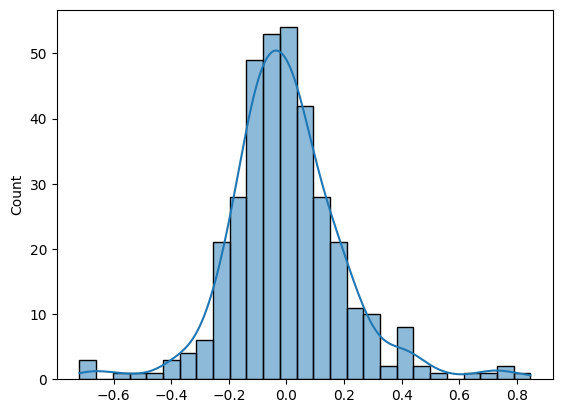

In [ ]:
#Check the normality of error terms
sb.histplot(residuals, kde = True)

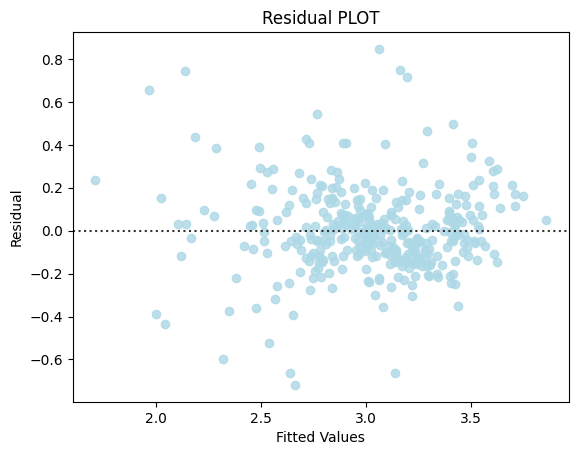

In [ ]:
#Check linear relationship of variables
fitted = ols_model_3.fittedvalues

sb.residplot(x = fitted, y = residuals, color = "lightblue")
plt.xlabel("Fitted Values")
plt.ylabel("Residual")
plt.title("Residual PLOT")
plt.show()

In [ ]:
#Check heteroscedasticity using Goldfeld–Quandt test
#pval >0.05 = no heteroscedasticity; pval <0.05 = heteroscedasticity present

from statsmodels.stats.diagnostic import het_white
from statsmodels.compat import lzip
import statsmodels.stats.api as sms
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(y_train, X_train_m3)
lzip(name, test)


[('F statistic', np.float64(1.1240332082806341)),
 ('p-value', np.float64(0.22470236835638752))]

Observations:


*   The mean of residuals is very close to 0, so the first assumption is statisfied.
*   The error terms are normally distributed, so the second assumption is statisfied.
*   The linearity of the residuals and fitted values show no correlation or pattern in the distribution. Importantly, there is no non-linear relationship displayed, thus the third assumption is statisfied.
*   The Goldfeld-Quandt test outputs a p-value greater than 0.05. Thus, there is no evidence of heteroscedasticity and the final assumption is statisfied.

As the assumptions of linear regression modeling have been statisfied, the output of Model 3 can be interpreted reliably.



## Final Model

Text(0.5, 1.0, 'Actual Median House Price (in $1000)')

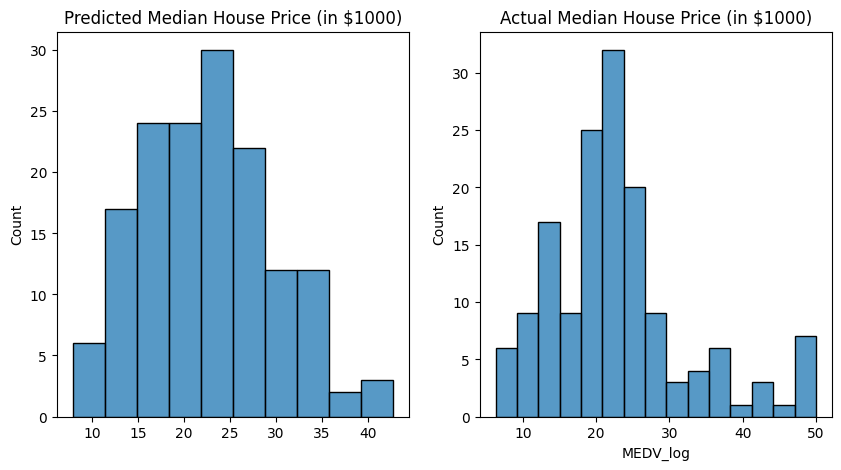

In [ ]:
#Drop variables from test dataset to match Model 3
X_test_updated = X_test.drop(columns=['INDUS', 'AGE', 'RAD', 'TAX'])

#Test model on test dataset
test_predictions = ols_model_3.predict(X_test_updated)
test_observed = y_test

#We used MEDV_log, so must account for log transformation
test_predictions_exp = np.exp(test_predictions)
test_observed_exp = np.exp(y_test)

#Plot predictions vs observed histogram plots
fig, axes = plt.subplots(1, 2, figsize = (10, 5))
sb.histplot(test_predictions_exp, ax = axes[0])
axes[0].set_title("Predicted Median House Price (in $1000)")
sb.histplot(test_observed_exp, ax = axes[1])
axes[1].set_title("Actual Median House Price (in $1000)")


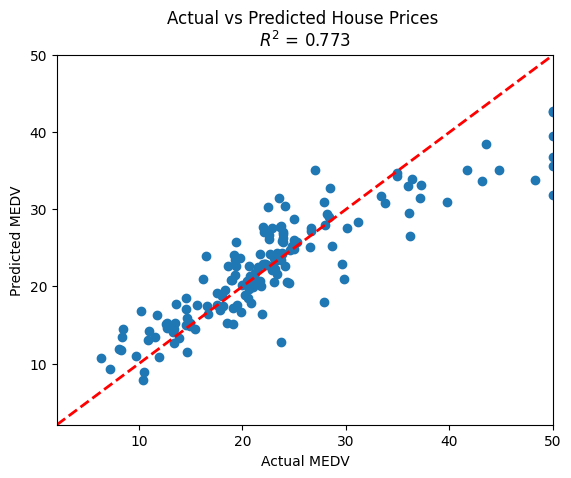

In [ ]:
#Plot scatter plot

r2 = r2_score(test_observed_exp, test_predictions_exp)
lims = [min(test_observed_exp.min(), test_predictions.min()),
        max(test_observed_exp.max(), test_predictions.max())]

plt.scatter(test_observed_exp, test_predictions_exp)
plt.plot(lims, lims, 'r--', linewidth=2)

plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title(f"Actual vs Predicted House Prices \n$R^2$ = {r2:.3f}")

plt.show()

In [ ]:
#Check model metrics on test dataset (using log transformed values is fine here, so it's comparable)

#Predict on train dataset, so you can compare model performance easily
train_predictions = ols_model_3.predict(X_train_m3)

metrics = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'R²': [
        r2_score(y_train, train_predictions),
        r2_score(y_test, test_predictions)
    ],
    'MAE': [
        mean_absolute_error(y_train, train_predictions),
        mean_absolute_error(y_test, test_predictions)
    ],
    'MSE': [
        mean_squared_error(y_train, train_predictions),
        mean_squared_error(y_test, test_predictions)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_train, train_predictions)),
        np.sqrt(mean_squared_error(y_test, test_predictions))
    ]
})

print(metrics.round(4))


  Dataset      R²     MAE     MSE    RMSE
0   Train  0.7593  0.1423  0.0395  0.1988
1    Test  0.7896  0.1443  0.0363  0.1905


In [ ]:
#Output coefs to help write the model equation
coef = ols_model_3.params
print(coef)

const      4.246229
CRIM      -0.009777
ZN         0.001300
CHAS       0.121885
NOX       -0.786589
RM         0.069460
DIS       -0.051618
PTRATIO   -0.033995
LSTAT     -0.029320
dtype: float64


Observations:

*   The model performs well on the test data compared to the training data, with nearly identical metrics observed for R-squared, MAE, MSE and RMSE.
*   The R-squared value is higher for the test dataset, which suggests the model may have underfitted the data slightly, but the difference is not large enough to cause concerns.
*   When comparing raw values from actual versus predicted house prices, the model performs well with high correlation. However, the model seems to not predict house prices over \$40,000 very well.


## Actionable Insights and Recommendations

Summary of analysis:

*   We have performed EDA to observe all the variables in the dataset and understand their relationships with each other.
*   We prepared the dataset for modeling by log transforming our dependent variable, MEDV, to account for the right skewness.
*   We built the model with all independent variables to start with, and iteratively removed insiginificant variables or variables with high multicollinearity.
*   We assessed the models' performance and checked it statisfied the assumptions of a linear regression model.
*   Finally, we tested the selected model on the test dataset, to evaluate it's performance and prediction on Boston house prices.


---

Conclusions:

*   The model performs well on the train and test dataset, with no strong evidence of overfitting or underfitting. The R-squared values are consistent and the graph displays good prediction of house prices with the following equation:

log (*MEDV*) = 4.246229 + (-0.009777)$*CRIM + (0.001300)*$ZN + (0.121885)$*CHAS + (-0.786589)*$NOX + (0.069460)$*RM + (-0.051618)*$DIS + (-0.033995)*$PTRATIO + (-0.029320)*$LSTAT

*   House prices are most influenced by:
    - CRIM: crime rate by town
    - ZN: proportional of land zones for lots
    - CHAS: location relative to the river
    - NOX: nitric oxide concentration
    - RM: average number of rooms per house
    - DIS: distance to Boston's employment centres
    - PTRATIO: pupil-teacher ratio by town
    - LSTAT: percentage of lower status in population

*   The model does not predict house prices above $40,000 well. This could be due to confounding factors that influence expensive house prices, such as the accessibility of radial highways (RAD) and the property-tax rate of the house (TAX).
*   Performing a multivariable regression model may help account for these factors and improve model performance. Or performing feature engineering, to create groups of low versus high accessibility to highways and low versus high property-tax rates.

---

Actionable Insights:


*   This model can be used to predict Boston house prices effectively up to \$40,000.
*   House prices are most influenced by nitric oxide concentration, if bound to Charles River and the number of rooms per house.
*   Retail agencies can use this model to predict a house price based on these key features, and buyers can use this model to see which characteristics most influence house price.



___